# Russian LLM Pretraining and Supervised Fine-Tuning

This notebook documents two complementary training experiments. First, it trains a compact decoder-only language model from random initialization on a Russian-literature corpus. Second, it performs supervised fine-tuning (SFT) of `Qwen/Qwen2.5-0.5B` on a Russian instruction-following dataset.

The notebook is designed as a **reproducible educational experiment**, not as a benchmark or a production model. It downloads public upstream resources programmatically and never commits source texts, model weights, checkpoints, or caches to the repository.

> **Compute note.** The full pretraining configuration is intentionally substantial: a roughly 132M-parameter model, 10 epochs, and sequences of up to 512 tokens. Run it on a suitable GPU environment such as Google Colab with a high-memory GPU. The SFT experiment also requires GPU memory. Start with the smoke-test configuration when validating the pipeline.


## Experiment design

**Part I — pretraining.** The source corpus is cloned from its upstream repository. Exact duplicate documents are removed, text is filtered and normalized, and a ByteLevel BPE tokenizer is trained from the resulting corpus. A Llama-style decoder-only model is then trained with causal-language-modeling loss. A fixed 95/5 split of text chunks provides a held-out validation loss and perplexity; the split is not a literary benchmark.

**Part II — supervised fine-tuning.** The Apache-2.0 Qwen2.5 0.5B base model is fine-tuned on a fixed, shuffled 5,000-example subset of the CC-BY-4.0 Russian `alpaca-cleaned-ru` dataset. The subset is split 90/10 into training and validation data. Pre- and post-SFT prompts are generated with the same chat-template structure. The validation loss and qualitative examples support inspection, but they do not establish factual accuracy, safety, or general instruction-following quality.


In [1]:
# Install dependencies in a fresh Colab runtime when needed.
%pip install -q "transformers>=4.45" "datasets>=2.20" "tokenizers>=0.20" "trl>=0.12" "accelerate>=0.34" sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.2 MB/s eta 0:00:00


In [2]:
import gc
import hashlib
import inspect
import random
import re
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import Dataset, load_dataset
from tokenizers import Tokenizer
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.trainers import BpeTrainer
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    DataCollatorForLanguageModeling,
    LlamaConfig,
    LlamaForCausalLM,
    PreTrainedTokenizerFast,
    Trainer,
    TrainingArguments,
    TrainerCallback,
)
from trl import SFTConfig, SFTTrainer

SEED = 42
CORPUS_REPOSITORY = 'https://github.com/JoannaBy/RussianNovels.git'
SFT_DATASET_NAME = 'd0rj/alpaca-cleaned-ru'
BASE_MODEL_NAME = 'Qwen/Qwen2.5-0.5B'

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'README.md').exists():
            return candidate
    return current

set_seed()
PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {device}')


Project root: /content
Device: cuda


## Part I — corpus acquisition and preparation

The upstream corpus is cloned at run time. It is not redistributed here. The original source describes the collection as material for stylometric experiments rather than as a balanced benchmark; review its provenance and the copyright status of individual texts before any use beyond this educational experiment.


In [3]:
CORPUS_DIR = DATA_DIR / 'RussianNovels'

if not CORPUS_DIR.exists():
    subprocess.run(
        ['git', 'clone', '--depth', '1', CORPUS_REPOSITORY, str(CORPUS_DIR)],
        check=True,
    )

TEXT_DIR = CORPUS_DIR / 'corpus'
if not TEXT_DIR.exists():
    raise FileNotFoundError(f'Expected corpus directory was not found: {TEXT_DIR}')

records = []
for path in sorted(TEXT_DIR.glob('*.txt')):
    text = path.read_text(encoding='utf-8', errors='ignore')
    records.append({'filename': path.name, 'text': text, 'n_characters': len(text)})

corpus_df = pd.DataFrame(records)
print(f'Loaded {len(corpus_df):,} text files with {corpus_df.n_characters.sum():,} characters.')
display(corpus_df[['filename', 'n_characters']].head())


Loaded 108 text files with 45,348,575 characters.


,filename,n_characters
0,Bulgakov_BelayaGvardiya.txt,504078
1,Bulgakov_Diavoliada.txt,70695
2,Bulgakov_Master.txt,775110
3,Bulgakov_RokovyeYaytsa.txt,147698
4,Bulgakov_TeatralnyjRoman.txt,294302


In [4]:
# Remove only exact duplicate documents. Repeated short dialogue turns remain in the corpus,
# because their frequency is part of the natural language distribution.
corpus_df['text_hash'] = corpus_df['text'].map(lambda text: hashlib.sha256(text.encode('utf-8')).hexdigest())
duplicate_mask = corpus_df.duplicated(subset='text_hash', keep='first')
duplicate_files = corpus_df.loc[duplicate_mask, 'filename'].tolist()
corpus_df = corpus_df.loc[~duplicate_mask].drop(columns='text_hash').reset_index(drop=True)

print(f'Removed {len(duplicate_files)} exact duplicate document(s): {duplicate_files or "none"}')
print(f'Retained {len(corpus_df):,} documents.')

def split_into_sentences(text: str) -> list[str]:
    pieces = re.split(r'(?<=[.!?])\s+', text)
    return [piece.strip() for piece in pieces if piece.strip()]

def is_mostly_cyrillic(text: str, threshold: float = 0.5) -> bool:
    letters = re.findall(r'[a-zA-Zа-яА-ЯёЁ]', text)
    if not letters:
        return False
    cyrillic = re.findall(r'[а-яА-ЯёЁ]', text)
    return len(cyrillic) / len(letters) >= threshold

def is_separator_line(text: str) -> bool:
    stripped = text.strip()
    if not stripped:
        return True
    non_alphanumeric = sum(not char.isalnum() and not char.isspace() for char in stripped)
    return non_alphanumeric / len(stripped) > 0.7

def normalize_punctuation(text: str) -> str:
    text = re.sub(r'\.{3,}', '...', text)
    text = re.sub(r'!{2,}', '!', text)
    text = re.sub(r'\?{2,}', '?', text)
    text = re.sub(r'[!?]{2,}', lambda match: '?!' if '?' in match.group() else match.group()[0], text)
    return re.sub(r'\s+', ' ', text).strip()

all_sentences = []
for text in corpus_df['text']:
    all_sentences.extend(split_into_sentences(text))

filtered_sentences = [
    sentence for sentence in all_sentences
    if is_mostly_cyrillic(sentence) and not is_separator_line(sentence)
]
normalized_sentences = [normalize_punctuation(sentence) for sentence in filtered_sentences]

print(f'Sentences before filtering: {len(all_sentences):,}')
print(f'Sentences after filtering:  {len(normalized_sentences):,}')


Removed 1 exact duplicate document(s): ['Vovchok_ZapiskiPrichyotnika.txt']
Retained 107 documents.
Sentences before filtering: 537,537
Sentences after filtering:  533,082


In [5]:
TARGET_CHUNK_CHARS = 1500

def chunk_sentences(sentences: list[str], target_chars: int = TARGET_CHUNK_CHARS) -> list[str]:
    chunks, current_chunk, current_length = [], [], 0
    for sentence in sentences:
        if current_chunk and current_length + len(sentence) + 1 > target_chars:
            chunks.append(' '.join(current_chunk))
            current_chunk, current_length = [], 0
        current_chunk.append(sentence)
        current_length += len(sentence) + 1
    if current_chunk:
        chunks.append(' '.join(current_chunk))
    return chunks

text_chunks = chunk_sentences(normalized_sentences)
chunk_lengths = np.array([len(chunk) for chunk in text_chunks])
print(f'Created {len(text_chunks):,} chunks.')
print(f'Chunk length (characters): median={np.median(chunk_lengths):.0f}, mean={chunk_lengths.mean():.0f}, max={chunk_lengths.max():.0f}')
print('\nExample chunk:\n', text_chunks[100][:500])


Created 30,488 chunks.
Chunk length (characters): median=1448, mean=1419, max=2062

Example chunk:
 Не зная еще, куда и зачем, Турбин захрустел рядом со взводом... Карась вывернулся из строя и, озабоченный, идя задом, начал считать: - Левой. Левой. Ать. Ать. В черную пасть подвального хода гимназии змеей втянулся строй, и пасть начала заглатывать ряд за рядом. Внутри гимназии было еще мертвеннее и мрачнее, чем снаружи. Каменную тишину и зыбкий сумрак брошенного здания быстро разбудило эхо военного шага. Под сводами стали летать какие-то звуки, точно проснулись демоны. Шорох и писк слышался в т


## Tokenizer, data split, and decoder-only model

A ByteLevel BPE tokenizer avoids the erroneous internal word spacing observed with the earlier whitespace-tokenizer attempt. The model architecture is intentionally compact relative to contemporary foundation models. The validation split is used only for monitoring and selecting the lowest validation loss checkpoint; it does not make this a general language-model benchmark.


In [6]:
VOCAB_SIZE = 3000
MAX_LENGTH = 512
TEST_SIZE = 0.05

tokenizer_raw = Tokenizer(BPE(unk_token='<unk>'))
tokenizer_raw.pre_tokenizer = ByteLevel(add_prefix_space=True)
tokenizer_raw.decoder = ByteLevelDecoder()
tokenizer_trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=['<pad>', '<bos>', '<eos>', '<unk>'],
    min_frequency=2,
)
tokenizer_raw.train_from_iterator(text_chunks, trainer=tokenizer_trainer)

pretrain_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer_raw,
    bos_token='<bos>',
    eos_token='<eos>',
    unk_token='<unk>',
    pad_token='<pad>',
)

def add_boundary_tokens(text: str) -> str:
    return f'{pretrain_tokenizer.bos_token} {text} {pretrain_tokenizer.eos_token}'

pretrain_dataset = Dataset.from_dict({'text': [add_boundary_tokens(chunk) for chunk in text_chunks]})
split_dataset = pretrain_dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

def tokenize_pretraining_batch(examples: dict) -> dict:
    return pretrain_tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
    )

tokenized_pretrain = split_dataset.map(
    tokenize_pretraining_batch,
    batched=True,
    remove_columns=['text'],
    desc='Tokenizing pretraining corpus',
)

pretrain_config = LlamaConfig(
    vocab_size=pretrain_tokenizer.vocab_size,
    hidden_size=1024,
    intermediate_size=1536,
    num_hidden_layers=16,
    num_attention_heads=16,
    num_key_value_heads=8,
    max_position_embeddings=MAX_LENGTH,
    bos_token_id=pretrain_tokenizer.bos_token_id,
    eos_token_id=pretrain_tokenizer.eos_token_id,
    pad_token_id=pretrain_tokenizer.pad_token_id,
)
pretrain_model = LlamaForCausalLM(pretrain_config)
n_parameters = sum(parameter.numel() for parameter in pretrain_model.parameters())

print(tokenized_pretrain)
print(f'Vocabulary size: {pretrain_tokenizer.vocab_size:,}')
print(f'Pretraining model parameters: {n_parameters:,} ({n_parameters / 1e6:.1f}M)')


Tokenizing pretraining corpus:   0%|          | 0/28963 [00:00<?, ? examples/s]

Tokenizing pretraining corpus:   0%|          | 0/1525 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 28963
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 1525
    })
})
Vocabulary size: 3,000
Pretraining model parameters: 132,006,912 (132.0M)


## Pretraining

Set `RUN_FULL_PRETRAINING` to `False` to perform a short smoke test. The smoke test validates data flow and code but is **not** meaningful training. The full configuration follows the documented 10-epoch setup. Checkpoints and trained artifacts are saved locally under `artifacts/` and excluded from version control.


In [7]:
RUN_FULL_PRETRAINING = True
FULL_EPOCHS = 10
SMOKE_TEST_EXAMPLES = 256
PRETRAIN_BATCH_SIZE = 64

if RUN_FULL_PRETRAINING:
    pretrain_train_dataset = tokenized_pretrain['train']
    pretrain_validation_dataset = tokenized_pretrain['test']
    num_train_epochs = FULL_EPOCHS
else:
    pretrain_train_dataset = tokenized_pretrain['train'].select(range(min(SMOKE_TEST_EXAMPLES, len(tokenized_pretrain['train']))))
    pretrain_validation_dataset = tokenized_pretrain['test'].select(range(min(64, len(tokenized_pretrain['test']))))
    num_train_epochs = 1

class PromptGenerationCallback(TrainerCallback):
    def __init__(self, tokenizer, prompts, every_n_epochs: int = 2, max_new_tokens: int = 40):
        self.tokenizer = tokenizer
        self.prompts = prompts
        self.every_n_epochs = every_n_epochs
        self.max_new_tokens = max_new_tokens

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        epoch = int(state.epoch)
        if epoch == 0 or epoch % self.every_n_epochs != 0:
            return
        model.eval()
        model_device = next(model.parameters()).device
        print(f'\nSample generations after epoch {epoch}:')
        for prompt in self.prompts:
            encoded = self.tokenizer(self.tokenizer.bos_token + ' ' + prompt, return_tensors='pt').to(model_device)
            with torch.no_grad():
                output = model.generate(
                    **encoded,
                    max_new_tokens=self.max_new_tokens,
                    do_sample=True,
                    top_p=0.9,
                    temperature=0.8,
                    pad_token_id=self.tokenizer.pad_token_id,
                )
            print(self.tokenizer.decode(output[0], skip_special_tokens=True))
        model.train()

training_kwargs = dict(
    output_dir=str(ARTIFACT_DIR / 'pretrain_checkpoints'),
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=PRETRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PRETRAIN_BATCH_SIZE,
    learning_rate=3e-4,
    weight_decay=0.01,
    lr_scheduler_type='cosine',
    logging_steps=50,
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    report_to='none',
    fp16=torch.cuda.is_available(),
    seed=SEED,
)
argument_names = inspect.signature(TrainingArguments).parameters
if 'eval_strategy' in argument_names:
    training_kwargs['eval_strategy'] = 'epoch'
else:
    training_kwargs['evaluation_strategy'] = 'epoch'

pretraining_args = TrainingArguments(**training_kwargs)
pretrain_collator = DataCollatorForLanguageModeling(tokenizer=pretrain_tokenizer, mlm=False)
generation_prompts = [
    'Все мысли, которые имеют огромные последствия',
    'Сила войска зависит от его духа',
    'Чтобы жить честно',
]

pretrain_trainer = Trainer(
    model=pretrain_model,
    args=pretraining_args,
    train_dataset=pretrain_train_dataset,
    eval_dataset=pretrain_validation_dataset,
    data_collator=pretrain_collator,
    callbacks=[PromptGenerationCallback(pretrain_tokenizer, generation_prompts)],
)

pretrain_result = pretrain_trainer.train()
pretrain_metrics = pretrain_trainer.evaluate()
pretrain_model = pretrain_trainer.model

pretrain_output_dir = ARTIFACT_DIR / 'russian_literature_pretrained'
pretrain_trainer.save_model(pretrain_output_dir)
pretrain_tokenizer.save_pretrained(pretrain_output_dir)

validation_loss = pretrain_metrics['eval_loss']
validation_perplexity = float(np.exp(validation_loss)) if validation_loss < 20 else float('inf')
print(f'Validation loss: {validation_loss:.4f}')
print(f'Validation perplexity: {validation_perplexity:.2f}')


Epoch,Training Loss,Validation Loss
1,3.755982,3.716186
2,3.358645,3.363975
3,3.117966,3.230991
4,2.892398,3.182653
5,2.638653,3.210464
6,2.315261,3.326083


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Sample generations after epoch 2:
 Все мысли, которые имеют огромные последствия, но в его отношении, как и этот раз, все-таки не имеет в жизни никакого права. Итак, не может быть, как не хочет. Этот человек,
 Сила войска зависит от его духа и жертвою. Если б он, по крайней мере, то я бы и сделался уверен, что бы ни был один, не смел бы, если бы не мог ни приз
 Чтобы жить честно, что в нем, то есть что-нибудь, есть что-нибудь важное. И не только, как они говорили, но даже и не замечая, что это ни с того, ни


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


Sample generations after epoch 10:
 Все мысли, которые имеют огромные последствия, следующие в третий раз, когда дело шло о набожных отношениях, об университете содержался известный обзор, чтобы вз
 Сила войска зависит от его духа в доме и смирения с детства, наряженных, не нарушая хитрого положения. Например, Пугачев с особенным удовольствием рассказывал
 Чтобы жить честно, он сказал, что, вероятно, плохо видит деревня, но что когда вечером ушел в сад, он, взглянув в небо, увидал на калит


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch
1.110665,3.182653,10


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Validation loss: 3.1827
Validation perplexity: 24.11


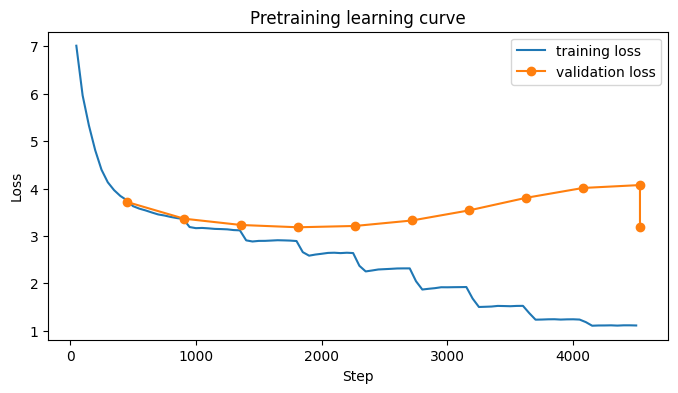

Prompt: Все мысли, которые имеют огромные последствия
 Все мысли, которые имеют огромные последствия, не мешавшие ему, но которые он давно привык видеть и которые он не мог, а все вместе, в ту минуту, когда ему приходилось жить наедине с ним, были такие же, как и он, такие же, которые он видел и слышал от одной, и другое, и более всех других. Начав в это время еще три дня, он опять с матерь 

Prompt: Сила войска зависит от его духа
 Сила войска зависит от его духа. -- Ваше превосходительство, ваше превосходительство, я должен бы мог, -- с изумлением заметила Дарья Александровна. -- О, вы знаете, я люблю вас, я люблю вас, я знаю. Это несправедливо. -- Вы не похожи на меня. Но не в духе, а в глазах моих, когда вы 

Prompt: Чтобы жить честно
 Чтобы жить честно и легко, он не знал, как это сделать; он, не любя себя, не любил, как его, и не любил и не любил, как он жил, и ему казалось, что он не только не женится на женщин, но и не может думать о ней, -- он любил этого не только и не умеющи

In [8]:
# Inspect the learning curves from the current run.
history = pd.DataFrame(pretrain_trainer.state.log_history)
fig, ax = plt.subplots(figsize=(8, 4))
if 'loss' in history:
    train_history = history.dropna(subset=['loss'])
    ax.plot(train_history['step'], train_history['loss'], label='training loss')
if 'eval_loss' in history:
    validation_history = history.dropna(subset=['eval_loss'])
    ax.plot(validation_history['step'], validation_history['eval_loss'], marker='o', label='validation loss')
ax.set(xlabel='Step', ylabel='Loss', title='Pretraining learning curve')
ax.legend()
plt.show()

pretrain_model.eval()
model_device = next(pretrain_model.parameters()).device
for prompt in generation_prompts:
    encoded = pretrain_tokenizer(pretrain_tokenizer.bos_token + ' ' + prompt, return_tensors='pt').to(model_device)
    with torch.no_grad():
        generated = pretrain_model.generate(
            **encoded,
            max_new_tokens=80,
            do_sample=True,
            top_p=0.9,
            temperature=0.8,
            pad_token_id=pretrain_tokenizer.pad_token_id,
        )
    print(f'Prompt: {prompt}')
    print(pretrain_tokenizer.decode(generated[0], skip_special_tokens=True), '\n')


## Part II — supervised fine-tuning of Qwen2.5-0.5B

This phase starts from the **base** Qwen2.5 0.5B model rather than from the small model trained above. That separation is deliberate: the pretraining section is a from-scratch demonstration, while SFT demonstrates instruction adaptation of a released base model. The base model is not intended for conversational use without post-training.


In [9]:
# Release the from-scratch model before loading Qwen in a memory-constrained environment.
del pretrain_model, pretrain_trainer, pretrain_result
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

qwen_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
if qwen_tokenizer.pad_token is None:
    qwen_tokenizer.pad_token = qwen_tokenizer.eos_token

qwen_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float32
qwen_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME, torch_dtype=qwen_dtype).to(device)
print(f'Loaded {BASE_MODEL_NAME} with dtype {qwen_dtype}.')


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Loaded Qwen/Qwen2.5-0.5B with dtype torch.bfloat16.


In [ ]:
SYSTEM_PROMPT = 'You are a helpful assistant.'
EVALUATION_QUESTIONS = [
    'Сколько планет в Солнечной системе?',
    'Расскажи короткое стихотворение о зиме.',
    'Когда обычно собирают крыжовник?',
    'Как построить привычку изучать новый язык?',
]

def build_chat_prompt(tokenizer, question: str) -> str:
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': question},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def generate_chat_answer(model, tokenizer, question: str, max_new_tokens: int = 150) -> str:
    prompt = build_chat_prompt(tokenizer, question)
    model_device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors='pt').to(model_device)
    im_end_id = tokenizer.convert_tokens_to_ids('<|im_end|>')
    eos_token_ids = [tokenizer.eos_token_id]
    if im_end_id is not None and im_end_id != tokenizer.unk_token_id:
        eos_token_ids.append(im_end_id)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            top_p=0.9,
            temperature=0.7,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=eos_token_ids,
        )
    answer_ids = output[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(answer_ids, skip_special_tokens=True)

# Store baseline generations before fine-tuning. These are qualitative examples, not scores.
qwen_model.eval()
baseline_answers = {
    question: generate_chat_answer(qwen_model, qwen_tokenizer, question)
    for question in EVALUATION_QUESTIONS
}
for question, answer in baseline_answers.items():
    print(f'Question: {question}\nBaseline answer: {answer}\n')


In [ ]:
SFT_SUBSET_SIZE = 5000
VALIDATION_FRACTION = 0.10

raw_sft_dataset = load_dataset(SFT_DATASET_NAME, split='train')

def to_messages(example: dict) -> dict:
    user_content = example['instruction']
    if example['input']:
        user_content += '\n\n' + example['input']
    return {
        'messages': [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': user_content},
            {'role': 'assistant', 'content': example['output']},
        ]
    }

sft_messages = raw_sft_dataset.map(to_messages, remove_columns=raw_sft_dataset.column_names)
sft_subset = sft_messages.shuffle(seed=SEED).select(range(min(SFT_SUBSET_SIZE, len(sft_messages))))
sft_split = sft_subset.train_test_split(test_size=VALIDATION_FRACTION, seed=SEED)

print(f'SFT training examples: {len(sft_split["train"]):,}')
print(f'SFT validation examples: {len(sft_split["test"]):,}')
print(sft_split['train'][0])


In [12]:
sft_kwargs = dict(
    output_dir=str(ARTIFACT_DIR / 'sft_checkpoints'),
    max_length=512,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    lr_scheduler_type='cosine',
    weight_decay=0.01,
    logging_steps=50,
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    report_to='none',
    fp16=False,
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    seed=SEED,
)
sft_argument_names = inspect.signature(SFTConfig).parameters
if 'eval_strategy' in sft_argument_names:
    sft_kwargs['eval_strategy'] = 'epoch'
else:
    sft_kwargs['evaluation_strategy'] = 'epoch'

sft_config = SFTConfig(**sft_kwargs)
sft_trainer = SFTTrainer(
    model=qwen_model,
    args=sft_config,
    train_dataset=sft_split['train'],
    eval_dataset=sft_split['test'],
    processing_class=qwen_tokenizer,
)

sft_result = sft_trainer.train()
sft_metrics = sft_trainer.evaluate()
sft_model = sft_trainer.model

sft_output_dir = ARTIFACT_DIR / 'qwen2.5-0.5b-russian-alpaca-sft'
sft_trainer.save_model(sft_output_dir)
qwen_tokenizer.save_pretrained(sft_output_dir)

print(f"SFT validation loss: {sft_metrics['eval_loss']:.4f}")


Tokenizing train dataset:   0%|          | 0/4500 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/4500 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/4500 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/4500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Training Loss,Validation Loss,Epoch,Entropy,Num Tokens,Mean Token Accuracy
1.234402,1.409918,3,1.430792,3436980.000000,0.677858


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SFT validation loss: 1.4099


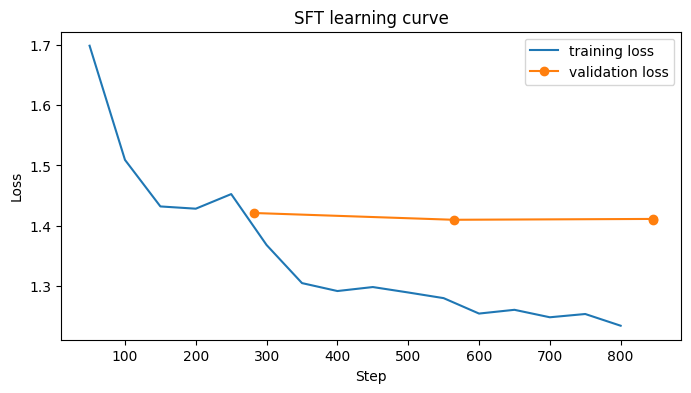

Question: Сколько планет в Солнечной системе?
Baseline answer: Это 8 планет в Солнечной системе!ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIndicator
ScrollIn

In [13]:
sft_history = pd.DataFrame(sft_trainer.state.log_history)
fig, ax = plt.subplots(figsize=(8, 4))
if 'loss' in sft_history:
    train_history = sft_history.dropna(subset=['loss'])
    ax.plot(train_history['step'], train_history['loss'], label='training loss')
if 'eval_loss' in sft_history:
    validation_history = sft_history.dropna(subset=['eval_loss'])
    ax.plot(validation_history['step'], validation_history['eval_loss'], marker='o', label='validation loss')
ax.set(xlabel='Step', ylabel='Loss', title='SFT learning curve')
ax.legend()
plt.show()

sft_model.eval()
post_sft_answers = {
    question: generate_chat_answer(sft_model, qwen_tokenizer, question)
    for question in EVALUATION_QUESTIONS
}

for question in EVALUATION_QUESTIONS:
    print(f'Question: {question}')
    print(f'Baseline answer: {baseline_answers[question]}')
    print(f'Post-SFT answer: {post_sft_answers[question]}')
    print('-' * 100)


## Interpretation and limitations

The notebook should be read as two **controlled training demonstrations**. For the pretraining component, the validation loss and perplexity describe performance only on a random chunk-level split drawn from the same collection. Sample continuations can illustrate stylistic patterns, but they do not establish grammatical correctness, factual knowledge, or broad Russian-language competence.

For the SFT component, held-out SFT loss indicates how well the model predicts examples from the sampled instruction dataset. The baseline/post-SFT generations are deliberately qualitative. They are insufficient for claims about truthfulness, safety, robustness, or real-world assistant quality. The supplied instruction data may contain factual errors or translation artifacts, so generated answers must be checked before use.

The notebook records code and experimental choices rather than publishing trained weights. Re-running it can produce different generations because sampling is stochastic and library or hardware versions may differ. Record the actual validation values, hardware, package versions, and representative outputs when reporting a completed run.
